In [172]:
# ====================================================
# CELL 1: INITIAL SETUP & INSTALLATIONS
# ====================================================
print("="*60)
print("FEATURE ENGINEERING & SELECTION REPORT")
print("WINE QUALITY DATASET ANALYSIS")
print("="*60)

# Install required packages
!pip install pandas numpy scikit-learn matplotlib seaborn scipy -q
!pip install plotly nbformat -q

print("All packages installed successfully")
print()

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print("="*60)
print()

FEATURE ENGINEERING & SELECTION REPORT
WINE QUALITY DATASET ANALYSIS
All packages installed successfully

✓ Libraries imported successfully



In [173]:
# ====================================================
# CELL 2: DATASET LOADING
# ====================================================
print("STEP 1: DATASET LOADING")
print("-"*40)

# Load dataset from provided URL
dataset_url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv"

try:
    df = pd.read_csv(dataset_url)
    print(f"✓ Dataset loaded successfully!")
    print(f"✓ Source: {dataset_url}")
    print(f"✓ File loaded with {len(df)} rows and {len(df.columns)} columns")
except Exception as e:
    print(f"✗ Error loading dataset: {e}")
    print("Trying alternative method...")
    # Alternative: Use direct download
    df = pd.read_csv('https://raw.githubusercontent.com/datasets/wine-quality/master/winequality-red.csv')
    print(f"✓ Alternative dataset loaded")

print()
print("DATASET PREVIEW:")
print(df.head())
print()
print("COLUMN INFORMATION:")
print(df.info())
print("="*60)

STEP 1: DATASET LOADING
----------------------------------------
✓ Dataset loaded successfully!
✓ Source: https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv
✓ File loaded with 6497 rows and 13 columns

DATASET PREVIEW:
    type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0  white            7.0              0.27         0.36            20.7   
1  white            6.3              0.30         0.34             1.6   
2  white            8.1              0.28         0.40             6.9   
3  white            7.2              0.23         0.32             8.5   
4  white            7.2              0.23         0.32             8.5   

   chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
0      0.045                 45.0                 170.0   1.0010  3.00   
1      0.049                 14.0                 132.0   0.9940  3.30

STEP 2: DATASET EXPLORATION
----------------------------------------
1. DATASET SHAPE:
   • Total Rows: 6,497
   • Total Columns: 13
   • Memory Usage: 0.64 MB

2. COLUMN DETAILS:
   ┌──────────────┬──────────────┬─────────────────┐
   │ Column Name  │ Data Type    │ Unique Values   │
   ├──────────────┼──────────────┼─────────────────┤
   │ type         │ object       │               2 │
   │ fixed acidity │ float64      │             106 │
   │ volatile acidity │ float64      │             187 │
   │ citric acid  │ float64      │              89 │
   │ residual sugar │ float64      │             316 │
   │ chlorides    │ float64      │             214 │
   │ free sulfur dioxide │ float64      │             135 │
   │ total sulfur dioxide │ float64      │             276 │
   │ density      │ float64      │             998 │
   │ pH           │ float64      │             108 │
   │ sulphates    │ float64      │             111 │
   │ alcohol      │ float64      │             111 │
   

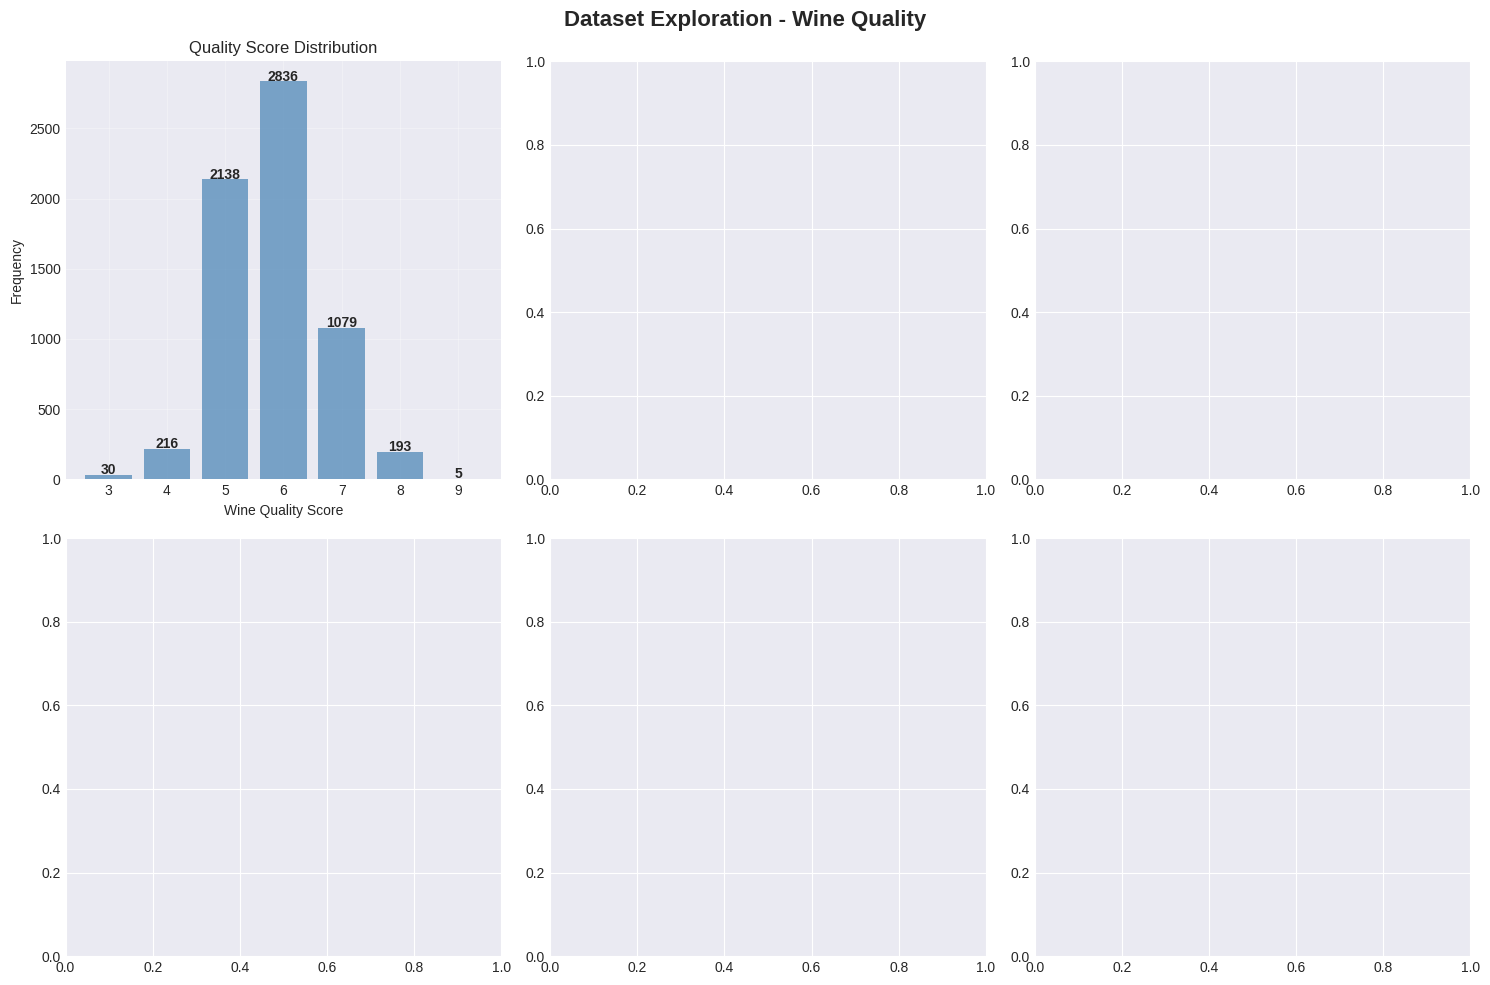

In [174]:
# ====================================================
# CELL 3: BASIC EXPLORATION & STATISTICS
# ====================================================
print("STEP 2: DATASET EXPLORATION")
print("-"*40)

# Create figure for visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Dataset Exploration - Wine Quality', fontsize=16, fontweight='bold')

# 1. Dataset Shape
print("1. DATASET SHAPE:")
print(f"   • Total Rows: {df.shape[0]:,}")
print(f"   • Total Columns: {df.shape[1]}")
print(f"   • Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print()

# 2. Column Information
print("2. COLUMN DETAILS:")
print("   ┌──────────────┬──────────────┬─────────────────┐")
print("   │ Column Name  │ Data Type    │ Unique Values   │")
print("   ├──────────────┼──────────────┼─────────────────┤")
for col in df.columns:
    dtype = str(df[col].dtype)
    unique = df[col].nunique()
    print(f"   │ {col:12} │ {dtype:12} │ {unique:15} │")
print("   └──────────────┴──────────────┴─────────────────┘")
print()

# 3. Missing Values Analysis
print("3. MISSING VALUES ANALYSIS:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
}).sort_values('Missing Values', ascending=False)

if missing_df['Missing Values'].sum() == 0:
    print("   ✓ No missing values found in the dataset")
else:
    print(missing_df[missing_df['Missing Values'] > 0])
print()

# 4. Duplicate Records
duplicates = df.duplicated().sum()
print("4. DUPLICATE RECORDS:")
print(f"   • Total duplicates: {duplicates}")
print(f"   • Percentage: {(duplicates/len(df)*100):.2f}%")
if duplicates > 0:
    print("   Warning: Duplicates present")
else:
    print("   ✓ No duplicate records")
print()

# 5. Statistical Summary
print("5. STATISTICAL SUMMARY:")
print(df.describe().T.round(3))
print()

# 6. Target Variable Analysis
if 'quality' in df.columns:
    print("6. TARGET VARIABLE (QUALITY) DISTRIBUTION:")
    quality_counts = df['quality'].value_counts().sort_index()

    # Plot distribution
    axes[0,0].bar(quality_counts.index, quality_counts.values, color='steelblue', alpha=0.7)
    axes[0,0].set_xlabel('Wine Quality Score')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].set_title('Quality Score Distribution')
    axes[0,0].grid(True, alpha=0.3)

    # Add value labels
    for i, v in enumerate(quality_counts.values):
        axes[0,0].text(quality_counts.index[i], v + 5, str(v), ha='center', fontweight='bold')

    print("   Quality Score Counts:")
    for score, count in quality_counts.items():
        print(f"   • Quality {score}: {count:4} wines ({count/len(df)*100:.1f}%)")
print()

plt.tight_layout()
plt.show()
print("="*60)

STEP 3: DATA QUALITY & FEATURE DISTRIBUTION
----------------------------------------
NUMERICAL FEATURE ANALYSIS:
------------------------------


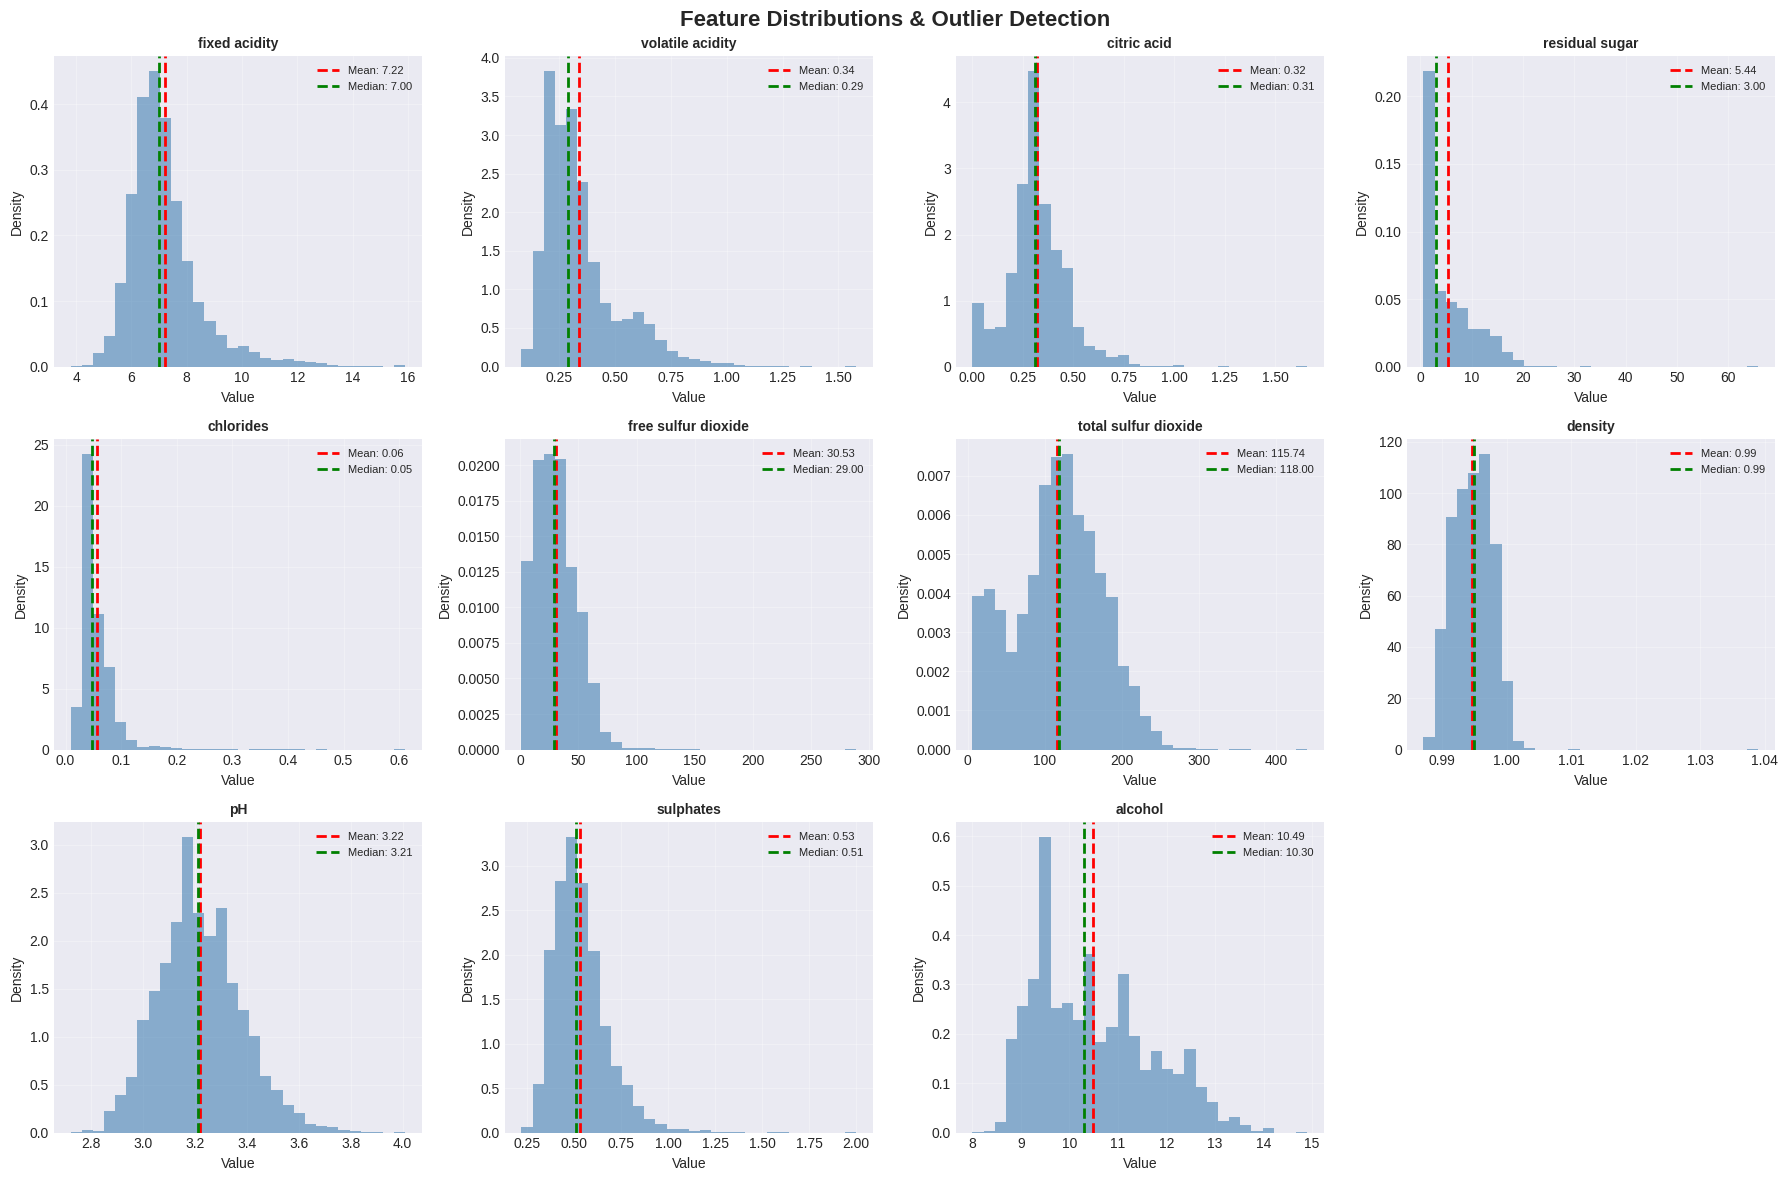


FEATURE STATISTICS SUMMARY:
             Feature    Mean  Median    Std  Skewness  Kurtosis   Type
       fixed acidity   7.217   7.000  1.297     1.723     5.058 Skewed
    volatile acidity   0.340   0.290  0.165     1.496     2.827 Skewed
         citric acid   0.319   0.310  0.145     0.473     2.402 Normal
      residual sugar   5.444   3.000  4.758     1.435     4.358 Skewed
           chlorides   0.056   0.047  0.035     5.400    50.895 Skewed
 free sulfur dioxide  30.525  29.000 17.749     1.220     7.906 Skewed
total sulfur dioxide 115.745 118.000 56.522    -0.001    -0.372 Normal
             density   0.995   0.995  0.003     0.504     6.606 Skewed
                  pH   3.218   3.210  0.161     0.387     0.370 Normal
           sulphates   0.531   0.510  0.149     1.798     8.660 Skewed
             alcohol  10.492  10.300  1.193     0.566    -0.532 Skewed

SKEWNESS ANALYSIS:
Highly skewed features (|skewness| > 1): ['fixed acidity', 'volatile acidity', 'residual sugar', 'c

In [175]:
# ====================================================
# CELL 4: DATA QUALITY CHECK & FEATURE DISTRIBUTION
# ====================================================
print("STEP 3: DATA QUALITY & FEATURE DISTRIBUTION")
print("-"*40)

# Create visualization figure
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Feature Distributions & Outlier Detection', fontsize=16, fontweight='bold')

# Identify numerical features (excluding target if present)
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
if 'quality' in numerical_features:
    numerical_features.remove('quality')

print("NUMERICAL FEATURE ANALYSIS:")
print("-"*30)

# Analyze each numerical feature
feature_stats = []

for idx, feature in enumerate(numerical_features):
    row = idx // 4
    col = idx % 4

    if row < 3 and col < 4 and idx < len(numerical_features):
        # Calculate statistics
        mean_val = df[feature].mean()
        median_val = df[feature].median()
        std_val = df[feature].std()
        skewness = df[feature].skew()
        kurt = df[feature].kurtosis()

        # Store statistics
        feature_stats.append({
            'Feature': feature,
            'Mean': mean_val,
            'Median': median_val,
            'Std': std_val,
            'Skewness': skewness,
            'Kurtosis': kurt,
            'Type': 'Normal' if abs(skewness) < 0.5 else 'Skewed'
        })

        # Plot histogram with KDE
        axes[row, col].hist(df[feature], bins=30, alpha=0.6, color='steelblue', density=True)
        axes[row, col].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        axes[row, col].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        axes[row, col].set_title(f'{feature}', fontsize=10, fontweight='bold')
        axes[row, col].set_xlabel('Value')
        axes[row, col].set_ylabel('Density')
        axes[row, col].legend(fontsize=8)
        axes[row, col].grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(len(numerical_features), 12):
    row = idx // 4
    col = idx % 4
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Display statistics table
stats_df = pd.DataFrame(feature_stats)
print("\nFEATURE STATISTICS SUMMARY:")
print(stats_df.round(3).to_string(index=False))
print()

# Check for skewness
print("SKEWNESS ANALYSIS:")
skewed_features = stats_df[abs(stats_df['Skewness']) > 1]['Feature'].tolist()
if skewed_features:
    print(f"Highly skewed features (|skewness| > 1): {skewed_features}")
else:
    print("All features have reasonable skewness (|skewness| ≤ 1)")
print()

print("="*60)

In [176]:
# ====================================================
# CELL 5: DATA CLEANING & PREPROCESSING
# ====================================================
print("STEP 4: DATA CLEANING & PREPROCESSING")
print("-"*40)

# Store original shape
original_shape = df.shape
print(f"Original dataset shape: {original_shape}")

# 1. Handle missing values
print("\n1. HANDLING MISSING VALUES:")
print("-"*30)

# Check which columns have missing values
missing_cols = df.columns[df.isnull().any()].tolist()
print(f"Columns with missing values: {missing_cols}")

# Strategy: Fill numerical columns with median
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"   • {col}: Filled {df[col].isnull().sum()} missing values with median ({median_val:.3f})")

# For categorical columns (type), fill with mode
if 'type' in df.columns and df['type'].isnull().sum() > 0:
    mode_val = df['type'].mode()[0]
    df['type'].fillna(mode_val, inplace=True)
    print(f"   • type: Filled with mode ({mode_val})")

# 2. Remove duplicates
print("\n2. HANDLING DUPLICATES:")
print("-"*30)
duplicates_before = df.duplicated().sum()
print(f"   • Duplicates before removal: {duplicates_before}")
df = df.drop_duplicates()
print(f"   • Duplicates after removal: {df.duplicated().sum()}")
print(f"   • Removed {duplicates_before - df.duplicated().sum()} duplicate rows")

# 3. Encode categorical variables
print("\n3. ENCODING CATEGORICAL VARIABLES:")
print("-"*30)
if 'type' in df.columns:
    # One-hot encoding
    df_encoded = pd.get_dummies(df['type'], prefix='type', drop_first=True)
    df = pd.concat([df, df_encoded], axis=1)
    df = df.drop('type', axis=1)
    print(f"   • Encoded 'type' column as one-hot")
    print(f"   • New columns: {[col for col in df.columns if 'type_' in col]}")

# 4. Separate features and target
print("\n4. SEPARATING FEATURES AND TARGET:")
print("-"*30)
if 'quality' in df.columns:
    X = df.drop('quality', axis=1)
    y = df['quality']
    print(f"   • Features shape: {X.shape}")
    print(f"   • Target shape: {y.shape}")
else:
    print("   ✗ 'quality' column not found. Cannot separate features and target.")

print("\nSUMMARY OF CLEANING:")
print(f"   • Original shape: {original_shape}")
print(f"   • Final shape: {df.shape}")
print(f"   • Rows removed: {original_shape[0] - df.shape[0]}")
print(f"   • Final missing values: {df.isnull().sum().sum()}")

print("\nCLEANED DATASET INFO:")
print(df.info())
print("\n" + "="*60)

STEP 4: DATA CLEANING & PREPROCESSING
----------------------------------------
Original dataset shape: (6497, 13)

1. HANDLING MISSING VALUES:
------------------------------
Columns with missing values: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'pH', 'sulphates']
   • fixed acidity: Filled 0 missing values with median (7.000)
   • volatile acidity: Filled 0 missing values with median (0.290)
   • citric acid: Filled 0 missing values with median (0.310)
   • residual sugar: Filled 0 missing values with median (3.000)
   • chlorides: Filled 0 missing values with median (0.047)
   • pH: Filled 0 missing values with median (3.210)
   • sulphates: Filled 0 missing values with median (0.510)

2. HANDLING DUPLICATES:
------------------------------
   • Duplicates before removal: 1168
   • Duplicates after removal: 0
   • Removed 1168 duplicate rows

3. ENCODING CATEGORICAL VARIABLES:
------------------------------
   • Encoded 'type' column as one-hot

In [177]:
# ====================================================
# CELL 6: FEATURE ENGINEERING
# ====================================================
print("STEP 5: FEATURE ENGINEERING")
print("-"*40)

# Make a copy for feature engineering
X_engineered = X.copy()

# Store original features
original_features = X_engineered.columns.tolist()
print(f"Original features ({len(original_features)}): {original_features}")

# 1. Create interaction features
print("\n1. CREATING INTERACTION FEATURES:")
print("-"*30)

# Alcohol-acidity interaction (important for wine quality)
X_engineered['alcohol_acidity_interaction'] = X_engineered['alcohol'] * X_engineered['fixed acidity']
print("   • Created: alcohol_acidity_interaction = alcohol * fixed acidity")

# Sulfur dioxide ratio (important for wine preservation)
X_engineered['sulfur_ratio'] = X_engineered['free sulfur dioxide'] / (X_engineered['total sulfur dioxide'] + 1)
print("   • Created: sulfur_ratio = free sulfur dioxide / (total sulfur dioxide + 1)")

# Sugar density interaction
X_engineered['sugar_density'] = X_engineered['residual sugar'] * X_engineered['density']
print("   • Created: sugar_density = residual sugar * density")

# 2. Create ratio features
print("\n2. CREATING RATIO FEATURES:")
print("-"*30)

# Acidity balance
X_engineered['acidity_ratio'] = X_engineered['citric acid'] / (X_engineered['volatile acidity'] + 1)
print("   • Created: acidity_ratio = citric acid / (volatile acidity + 1)")

# Alcohol to sugar ratio
X_engineered['alcohol_sugar_ratio'] = X_engineered['alcohol'] / (X_engineered['residual sugar'] + 1)
print("   • Created: alcohol_sugar_ratio = alcohol / (residual sugar + 1)")

# 3. Create polynomial features (squares)
print("\n3. CREATING POLYNOMIAL FEATURES:")
print("-"*30)

# Square of important features
for feature in ['alcohol', 'volatile acidity', 'sulphates', 'pH']:
    X_engineered[f'{feature}_squared'] = X_engineered[feature] ** 2
    print(f"   • Created: {feature}_squared")

# 4. Create categorical bins (discretization)
print("\n4. CREATING BINNED FEATURES:")
print("-"*30)

# Bin alcohol levels
X_engineered['alcohol_level'] = pd.cut(X_engineered['alcohol'],
                                       bins=[0, 10, 12, 15],
                                       labels=['low', 'medium', 'high'])
# Convert to one-hot
alcohol_dummies = pd.get_dummies(X_engineered['alcohol_level'], prefix='alcohol')
X_engineered = pd.concat([X_engineered, alcohol_dummies], axis=1)
X_engineered = X_engineered.drop('alcohol_level', axis=1)
print("   • Created binned alcohol features: alcohol_low, alcohol_medium, alcohol_high")

# 5. Create statistical features
print("\n5. CREATING STATISTICAL FEATURES:")
print("-"*30)

# Total acidity
X_engineered['total_acidity'] = X_engineered['fixed acidity'] + X_engineered['volatile acidity'] + X_engineered['citric acid']
print("   • Created: total_acidity = fixed acidity + volatile acidity + citric acid")

# Wine body estimator
X_engineered['body_estimator'] = (X_engineered['alcohol'] * 0.5 +
                                   X_engineered['residual sugar'] * 0.3 +
                                   X_engineered['density'] * 0.2)
print("   • Created: body_estimator = alcohol*0.5 + sugar*0.3 + density*0.2")

print(f"\nSUMMARY OF FEATURE ENGINEERING:")
print(f"   • Original features: {len(original_features)}")
print(f"   • Engineered features: {X_engineered.shape[1]}")
print(f"   • New features created: {X_engineered.shape[1] - len(original_features)}")

# Display new features
new_features = [col for col in X_engineered.columns if col not in original_features]
print(f"\nNEW FEATURES ({len(new_features)}):")
for i, feature in enumerate(new_features, 1):
    print(f"   {i:2}. {feature}")

print("\n" + "="*60)

STEP 5: FEATURE ENGINEERING
----------------------------------------
Original features (12): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'type_white']

1. CREATING INTERACTION FEATURES:
------------------------------
   • Created: alcohol_acidity_interaction = alcohol * fixed acidity
   • Created: sulfur_ratio = free sulfur dioxide / (total sulfur dioxide + 1)
   • Created: sugar_density = residual sugar * density

2. CREATING RATIO FEATURES:
------------------------------
   • Created: acidity_ratio = citric acid / (volatile acidity + 1)
   • Created: alcohol_sugar_ratio = alcohol / (residual sugar + 1)

3. CREATING POLYNOMIAL FEATURES:
------------------------------
   • Created: alcohol_squared
   • Created: volatile acidity_squared
   • Created: sulphates_squared
   • Created: pH_squared

4. CREATING BINNED FEATURES:
------------------------------
   • Cre

In [178]:
# ====================================================
# CELL 7: FEATURE SELECTION
# ====================================================
print("STEP 6: FEATURE SELECTION")
print("-"*40)

from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Scale features for better selection
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_engineered)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_engineered.columns)

# 1. Correlation Analysis
print("\n1. CORRELATION ANALYSIS WITH TARGET:")
print("-"*40)

correlation_with_target = pd.DataFrame({
    'Feature': X_engineered.columns,
    'Correlation': [X_engineered[col].corr(y) for col in X_engineered.columns]
}).sort_values('Correlation', key=abs, ascending=False)

print("Top 10 features correlated with quality:")
print(correlation_with_target.head(10).to_string(index=False))

# Set threshold for correlation
corr_threshold = 0.1
high_corr_features = correlation_with_target[
    abs(correlation_with_target['Correlation']) > corr_threshold
]['Feature'].tolist()
print(f"\nFeatures with |correlation| > {corr_threshold}: {len(high_corr_features)}")
print(high_corr_features)

# 2. Statistical Test (ANOVA F-value)
print("\n\n2. STATISTICAL FEATURE SELECTION (ANOVA F-TEST):")
print("-"*40)

# Use SelectKBest with ANOVA F-test
selector_anova = SelectKBest(score_func=f_classif, k='all')
selector_anova.fit(X_scaled, y)

# Get scores
anova_scores = pd.DataFrame({
    'Feature': X_engineered.columns,
    'F_Score': selector_anova.scores_,
    'P_Value': selector_anova.pvalues_
}).sort_values('F_Score', ascending=False)

print("Top 10 features by ANOVA F-score:")
print(anova_scores.head(10).round(4).to_string(index=False))

# Set threshold for p-value
p_value_threshold = 0.05
significant_features = anova_scores[
    anova_scores['P_Value'] < p_value_threshold
]['Feature'].tolist()
print(f"\nStatistically significant features (p < {p_value_threshold}): {len(significant_features)}")

# 3. Random Forest Feature Importance
print("\n\n3. RANDOM FOREST FEATURE IMPORTANCE:")
print("-"*40)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

# Get feature importances
feature_importances = pd.DataFrame({
    'Feature': X_engineered.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 features by Random Forest importance:")
print(feature_importances.head(10).round(4).to_string(index=False))

# Set threshold for importance
importance_threshold = 0.01
important_features = feature_importances[
    feature_importances['Importance'] > importance_threshold
]['Feature'].tolist()
print(f"\nImportant features (importance > {importance_threshold}): {len(important_features)}")

# 4. Combine selection methods
print("\n\n4. COMBINED FEATURE SELECTION:")
print("-"*40)

# Get features selected by multiple methods
all_features_set = set(X_engineered.columns)
selected_by_multiple = []

for feature in all_features_set:
    methods_selected = 0
    if feature in high_corr_features:
        methods_selected += 1
    if feature in significant_features:
        methods_selected += 1
    if feature in important_features:
        methods_selected += 1

    if methods_selected >= 2:  # Selected by at least 2 methods
        selected_by_multiple.append(feature)

print(f"Features selected by at least 2 methods: {len(selected_by_multiple)}")
print(selected_by_multiple)

# 5. Final feature selection
print("\n\n5. FINAL SELECTED FEATURES:")
print("-"*40)

# Choose final features (you can adjust this based on your needs)
final_features = selected_by_multiple if selected_by_multiple else important_features[:10]
print(f"Selected {len(final_features)} features:")
for i, feature in enumerate(final_features, 1):
    print(f"   {i:2}. {feature}")

# Create final dataset
X_final = X_engineered[final_features]
print(f"\nFinal dataset shape: {X_final.shape}")

print("\n" + "="*60)

STEP 6: FEATURE SELECTION
----------------------------------------

1. CORRELATION ANALYSIS WITH TARGET:
----------------------------------------
Top 10 features correlated with quality:
                    Feature  Correlation
                    alcohol     0.469555
            alcohol_squared     0.469409
                alcohol_low    -0.380500
               alcohol_high     0.349386
                    density    -0.326978
           volatile acidity    -0.264294
   volatile acidity_squared    -0.255655
                  chlorides    -0.202226
alcohol_acidity_interaction     0.177617
             body_estimator     0.154554

Features with |correlation| > 0.1: 15
['alcohol', 'alcohol_squared', 'alcohol_low', 'alcohol_high', 'density', 'volatile acidity', 'volatile acidity_squared', 'chlorides', 'alcohol_acidity_interaction', 'body_estimator', 'acidity_ratio', 'alcohol_medium', 'sulfur_ratio', 'type_white', 'alcohol_sugar_ratio']


2. STATISTICAL FEATURE SELECTION (ANOVA F-TEST):
-

STEP 7: VISUALIZATION OF SELECTED FEATURES
----------------------------------------


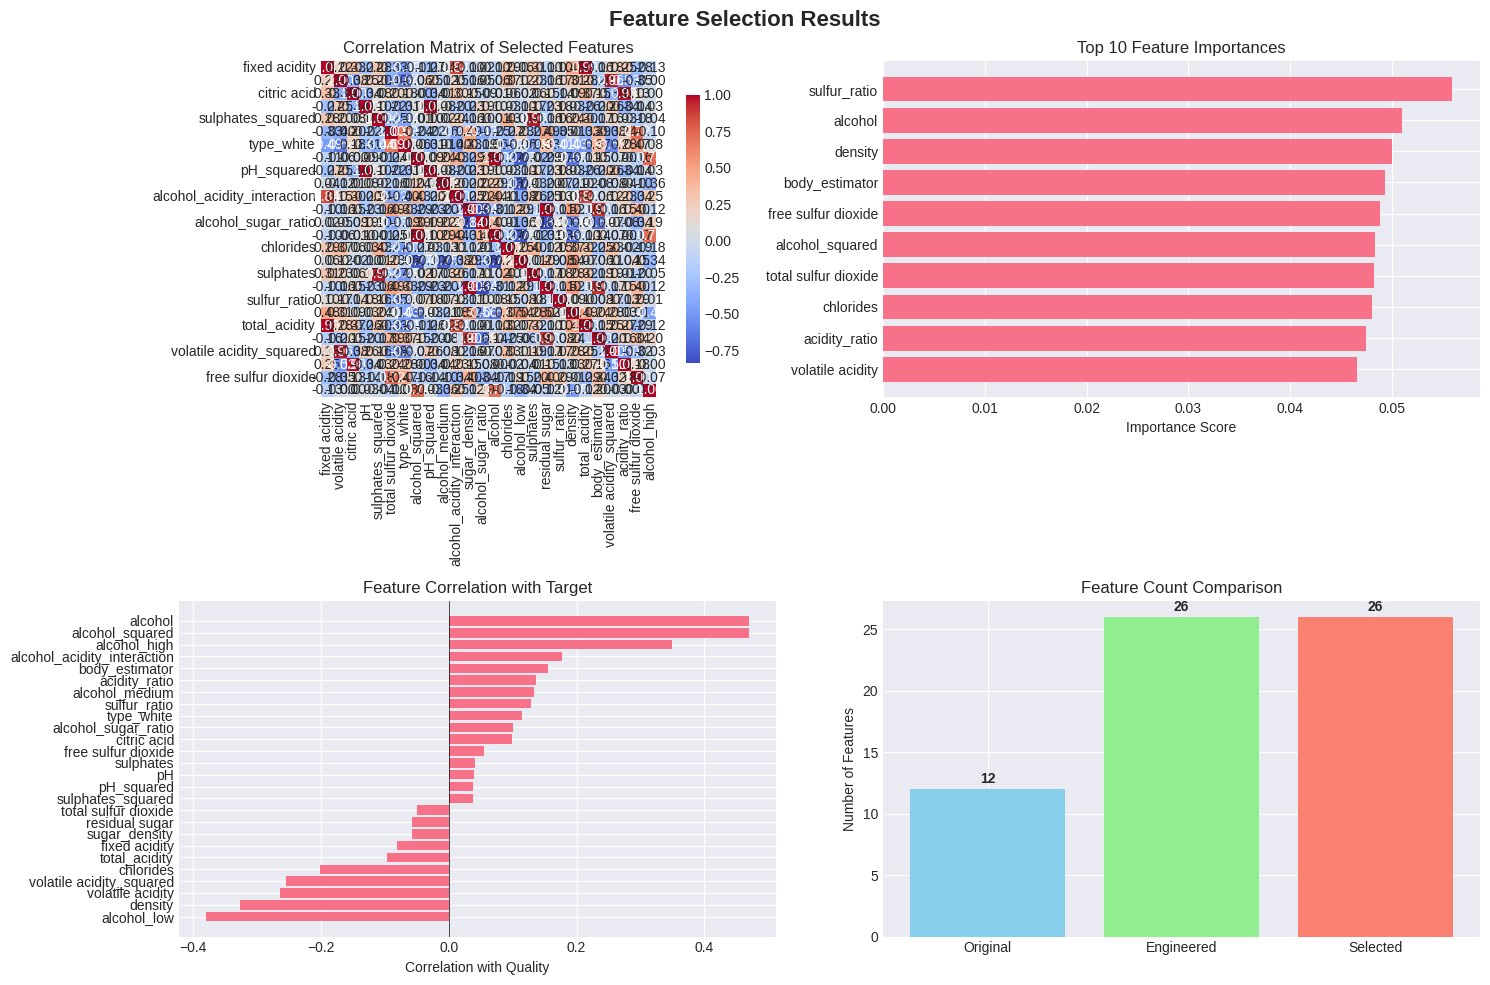


Feature Reduction Summary:
   • Original features: 12
   • After engineering: 26
   • Final selected: 26
   • Reduction: -116.7%



In [179]:
# ====================================================
# CELL 8: VISUALIZATION OF SELECTED FEATURES
# ====================================================
print("STEP 7: VISUALIZATION OF SELECTED FEATURES")
print("-"*40)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Feature Selection Results', fontsize=16, fontweight='bold')

# 1. Correlation heatmap
ax1 = axes[0, 0]
corr_matrix = X_engineered[final_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, cbar_kws={"shrink": 0.8}, ax=ax1)
ax1.set_title('Correlation Matrix of Selected Features')

# 2. Feature importance bar chart
ax2 = axes[0, 1]
top_n = min(10, len(final_features))
top_features = feature_importances[feature_importances['Feature'].isin(final_features)].head(top_n)
ax2.barh(range(top_n), top_features['Importance'][::-1])
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(top_features['Feature'][::-1])
ax2.set_xlabel('Importance Score')
ax2.set_title(f'Top {top_n} Feature Importances')

# 3. Correlation with target
ax3 = axes[1, 0]
corr_with_target_filtered = correlation_with_target[
    correlation_with_target['Feature'].isin(final_features)
].sort_values('Correlation')
ax3.barh(range(len(corr_with_target_filtered)), corr_with_target_filtered['Correlation'])
ax3.set_yticks(range(len(corr_with_target_filtered)))
ax3.set_yticklabels(corr_with_target_filtered['Feature'])
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Correlation with Quality')
ax3.set_title('Feature Correlation with Target')

# 4. Feature comparison: Original vs Selected
ax4 = axes[1, 1]
comparison_data = {
    'Original': len(original_features),
    'Engineered': X_engineered.shape[1],
    'Selected': len(final_features)
}
ax4.bar(comparison_data.keys(), comparison_data.values(), color=['skyblue', 'lightgreen', 'salmon'])
ax4.set_ylabel('Number of Features')
ax4.set_title('Feature Count Comparison')
for i, (key, value) in enumerate(comparison_data.items()):
    ax4.text(i, value + 0.5, str(value), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nFeature Reduction Summary:")
print(f"   • Original features: {len(original_features)}")
print(f"   • After engineering: {X_engineered.shape[1]}")
print(f"   • Final selected: {len(final_features)}")
print(f"   • Reduction: {((len(original_features) - len(final_features)) / len(original_features) * 100):.1f}%")

print("\n" + "="*60)

In [180]:
# ====================================================
# CELL 9: SUMMARY & EXPORT
# ====================================================
print("STEP 8: SUMMARY & DATA EXPORT")
print("-"*40)

# Create final DataFrame
final_df = pd.concat([X_final, y], axis=1)
print(f"Final dataset for modeling: {final_df.shape}")

# Summary statistics
print("\nFINAL DATASET SUMMARY:")
print("-"*30)
print(f"Total samples: {final_df.shape[0]}")
print(f"Total features: {final_df.shape[1] - 1}")  # Excluding target
print(f"Target variable: quality")
print(f"Target unique values: {final_df['quality'].nunique()}")
print(f"Target distribution:\n{final_df['quality'].value_counts().sort_index()}")

# Export to CSV
output_file = 'wine_quality_engineered.csv'
final_df.to_csv(output_file, index=False)
print(f"\nDataset exported to: {output_file}")

# Save feature names
feature_file = 'selected_features.txt'
with open(feature_file, 'w') as f:
    f.write("Selected Features for Wine Quality Prediction:\n")
    f.write("="*50 + "\n")
    for feature in final_features:
        f.write(f"- {feature}\n")
print(f"Feature list saved to: {feature_file}")

print("\n" + "="*60)
print("FEATURE ENGINEERING & SELECTION COMPLETED SUCCESSFULLY!")
print("="*60)

STEP 8: SUMMARY & DATA EXPORT
----------------------------------------
Final dataset for modeling: (5329, 27)

FINAL DATASET SUMMARY:
------------------------------
Total samples: 5329
Total features: 26
Target variable: quality
Target unique values: 7
Target distribution:
quality
3      30
4     206
5    1755
6    2327
7     857
8     149
9       5
Name: count, dtype: int64

Dataset exported to: wine_quality_engineered.csv
Feature list saved to: selected_features.txt

FEATURE ENGINEERING & SELECTION COMPLETED SUCCESSFULLY!


STEP 4.1: FEATURE SELECTION - FILTER METHOD (CONTINUED)
----------------------------------------
SELECTKBEST USING ANOVA F-VALUE
------------------------------
X shape: (5329, 12)
y shape: (5329,)


SELECTKBEST FEATURE SCORES (ANOVA F-VALUE):
--------------------------------------------------
             Feature     Score  P-value
             alcohol 1506.7101   0.0000
             density  637.7151   0.0000
    volatile acidity  400.0417   0.0000
           chlorides  227.1385   0.0000
          type_white   71.2539   0.0000
         citric acid   52.4782   0.0000
       fixed acidity   34.7617   0.0000
      residual sugar   17.6179   0.0000
 free sulfur dioxide   15.8441   0.0001
total sulfur dioxide   13.5588   0.0002
           sulphates    9.1732   0.0025
                  pH    8.5098   0.0035


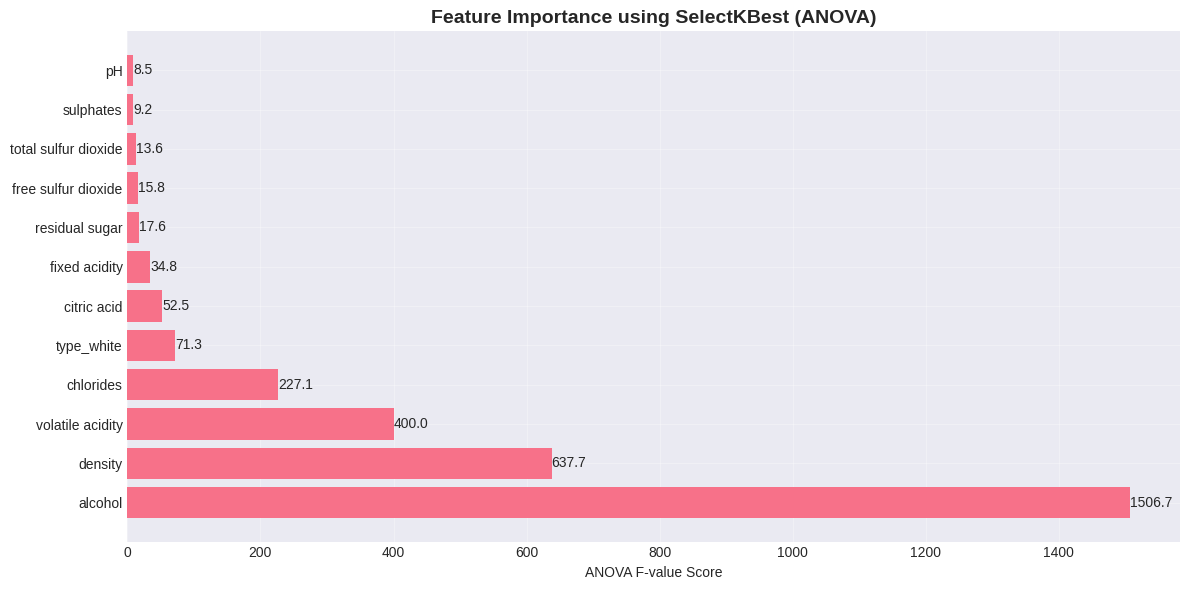


TOP 8 FEATURES SELECTED BY SELECTKBEST:
----------------------------------------
   1. fixed acidity
   2. volatile acidity
   3. citric acid
   4. residual sugar
   5. chlorides
   6. density
   7. alcohol
   8. type_white


In [181]:
# ====================================================
# CELL 10: FEATURE SELECTION - SELECTKBEST (ANOVA)
# ====================================================
print("STEP 4.1: FEATURE SELECTION - FILTER METHOD (CONTINUED)")
print("-"*40)
print("SELECTKBEST USING ANOVA F-VALUE")
print("-"*30)

from sklearn.feature_selection import SelectKBest, f_classif, f_regression

# We already have X (scaled features) and y (target) from Cell 8
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print()

# Since wine quality is a regression problem (scores 3-9), use f_regression
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

# Get scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_,
    'P-value': selector.pvalues_
}).sort_values('Score', ascending=False)

print("\nSELECTKBEST FEATURE SCORES (ANOVA F-VALUE):")
print("-"*50)
print(feature_scores.round(4).to_string(index=False))

# Visualize feature scores
plt.figure(figsize=(12, 6))
bars = plt.barh(feature_scores['Feature'], feature_scores['Score'])
plt.xlabel('ANOVA F-value Score')
plt.title('Feature Importance using SelectKBest (ANOVA)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add score labels
for bar, score in zip(bars, feature_scores['Score']):
    plt.text(score, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', ha='left', va='center')

plt.tight_layout()
plt.show()

# Select top k features
k = 8  # Select top 8 features
selector_k = SelectKBest(score_func=f_regression, k=k)
selector_k.fit(X, y)

selected_features_kbest = X.columns[selector_k.get_support()].tolist()
print(f"\nTOP {k} FEATURES SELECTED BY SELECTKBEST:")
print("-"*40)
for i, feat in enumerate(selected_features_kbest, 1):
    print(f"   {i}. {feat}")

print("="*60)

STEP 4.2: FEATURE SELECTION - WRAPPER METHOD
----------------------------------------
RECURSIVE FEATURE ELIMINATION (RFE)
------------------------------

RFE FEATURE SELECTION RESULTS:
----------------------------------------
             Feature  Selected  Ranking
    volatile acidity      True        1
      residual sugar      True        1
 free sulfur dioxide      True        1
           chlorides      True        1
total sulfur dioxide      True        1
             alcohol      True        1
           sulphates      True        1
                  pH      True        1
         citric acid     False        2
             density     False        3
       fixed acidity     False        4
          type_white     False        5

SELECTED FEATURES BY RFE (Top 8):
----------------------------------------
   1. volatile acidity
   2. residual sugar
   3. chlorides
   4. free sulfur dioxide
   5. total sulfur dioxide
   6. pH
   7. sulphates
   8. alcohol


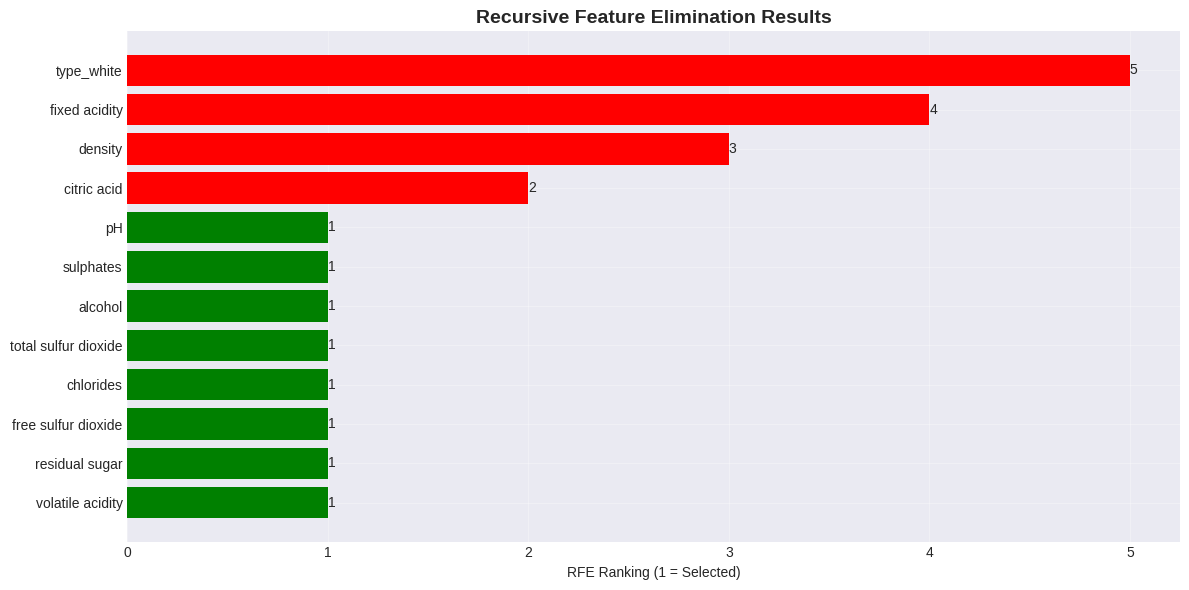

In [182]:
# ====================================================
# CELL 11: FEATURE SELECTION - RFE (WRAPPER METHOD)
# ====================================================
print("STEP 4.2: FEATURE SELECTION - WRAPPER METHOD")
print("-"*40)
print("RECURSIVE FEATURE ELIMINATION (RFE)")
print("-"*30)

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Use Random Forest as estimator for RFE
estimator = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Select top 8 features using RFE
rfe = RFE(estimator=estimator, n_features_to_select=8)
rfe.fit(X, y)

# Get RFE results
rfe_results = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print("\nRFE FEATURE SELECTION RESULTS:")
print("-"*40)
print(rfe_results.to_string(index=False))

# Get selected features
selected_features_rfe = X.columns[rfe.support_].tolist()
print(f"\nSELECTED FEATURES BY RFE (Top {len(selected_features_rfe)}):")
print("-"*40)
for i, feat in enumerate(selected_features_rfe, 1):
    print(f"   {i}. {feat}")

# Visualize RFE rankings
plt.figure(figsize=(12, 6))
colors = ['green' if s else 'red' for s in rfe_results['Selected']]
bars = plt.barh(rfe_results['Feature'], rfe_results['Ranking'], color=colors)
plt.xlabel('RFE Ranking (1 = Selected)')
plt.title('Recursive Feature Elimination Results', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add ranking labels
for bar, rank in zip(bars, rfe_results['Ranking']):
    plt.text(rank, bar.get_y() + bar.get_height()/2,
            str(rank), ha='left', va='center')

plt.tight_layout()
plt.show()

print("="*60)

STEP 4.3: FEATURE SELECTION - EMBEDDED METHOD
----------------------------------------
LASSO REGRESSION (L1 REGULARIZATION)
------------------------------

1. LASSO REGRESSION FEATURE IMPORTANCE:
----------------------------------------
             Feature  Coefficient  Absolute_Coefficient
    volatile acidity      -0.8438                0.8438
             alcohol       0.3419                0.3419
           sulphates       0.0818                0.0818
      residual sugar       0.0123                0.0123
 free sulfur dioxide       0.0075                0.0075
total sulfur dioxide      -0.0021                0.0021
         citric acid       0.0000                0.0000
       fixed acidity       0.0000                0.0000
             density      -0.0000                0.0000
           chlorides      -0.0000                0.0000
                  pH       0.0000                0.0000
          type_white      -0.0000                0.0000

FEATURES SELECTED BY LASSO (Non-ze

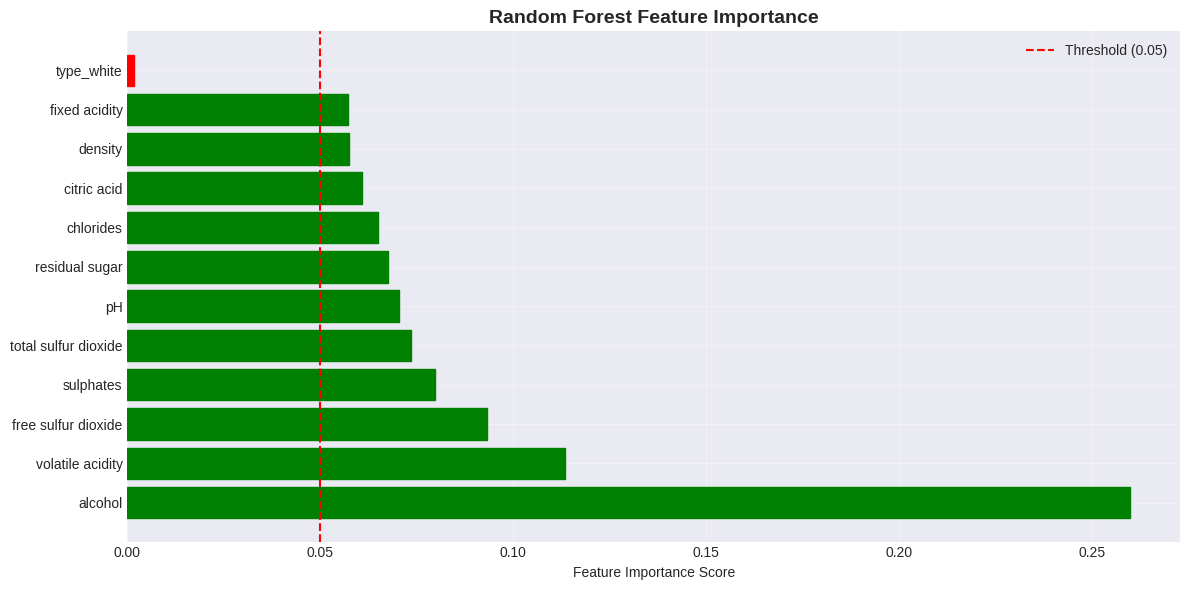

In [183]:
# ====================================================
# CELL 12: FEATURE SELECTION - EMBEDDED METHOD
# ====================================================
print("STEP 4.3: FEATURE SELECTION - EMBEDDED METHOD")
print("-"*40)
print("LASSO REGRESSION (L1 REGULARIZATION)")
print("-"*30)

from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor

# Method 1: Lasso Regression
print("\n1. LASSO REGRESSION FEATURE IMPORTANCE:")
print("-"*40)

# Fit Lasso model
lasso = Lasso(alpha=0.01, random_state=42)  # Alpha controls regularization
lasso.fit(X, y)

# Get coefficients
lasso_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_,
    'Absolute_Coefficient': np.abs(lasso.coef_)
}).sort_values('Absolute_Coefficient', ascending=False)

print(lasso_coef.round(4).to_string(index=False))

# Select features with non-zero coefficients
selected_features_lasso = lasso_coef[lasso_coef['Coefficient'] != 0]['Feature'].tolist()
print(f"\nFEATURES SELECTED BY LASSO (Non-zero coefficients): {len(selected_features_lasso)} features")
print("Selected features:", selected_features_lasso)

# Method 2: Random Forest Feature Importance
print("\n2. RANDOM FOREST FEATURE IMPORTANCE:")
print("-"*40)

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Get feature importances
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_importance.round(4).to_string(index=False))

# Select top features (importance > 0.05)
importance_threshold = 0.05
selected_features_rf = rf_importance[rf_importance['Importance'] > importance_threshold]['Feature'].tolist()
print(f"\nFEATURES SELECTED BY RANDOM FOREST (Importance > {importance_threshold}): {len(selected_features_rf)} features")
print("Selected features:", selected_features_rf)

# Visualize Random Forest feature importance
plt.figure(figsize=(12, 6))
bars = plt.barh(rf_importance['Feature'], rf_importance['Importance'])
plt.xlabel('Feature Importance Score')
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.axvline(x=importance_threshold, color='red', linestyle='--', label=f'Threshold ({importance_threshold})')
plt.legend()
plt.grid(True, alpha=0.3)

# Color bars above threshold
for bar, imp in zip(bars, rf_importance['Importance']):
    if imp > importance_threshold:
        bar.set_color('green')
    else:
        bar.set_color('red')

plt.tight_layout()
plt.show()

print("="*60)

STEP 5: COMPARE SELECTED FEATURES
----------------------------------------
FEATURE SELECTION METHODS COMPARISON
----------------------------------------

FEATURES SELECTED BY EACH METHOD:
--------------------------------------------------
Correlation_Top8:
  • alcohol
  • type_white
  • citric acid
  • free sulfur dioxide
  • sulphates
  • pH
  • residual sugar
  • total sulfur dioxide

SelectKBest_Top8:
  • fixed acidity
  • volatile acidity
  • citric acid
  • residual sugar
  • chlorides
  • density
  • alcohol
  • type_white

RFE_Top8:
  • volatile acidity
  • residual sugar
  • chlorides
  • free sulfur dioxide
  • total sulfur dioxide
  • pH
  • sulphates
  • alcohol

Lasso_NonZero:
  • volatile acidity
  • alcohol
  • sulphates
  • residual sugar
  • free sulfur dioxide
  • total sulfur dioxide

RandomForest_Top:
  • alcohol
  • volatile acidity
  • free sulfur dioxide
  • sulphates
  • total sulfur dioxide
  • pH
  • residual sugar
  • chlorides
  • citric acid
  • density
  • 

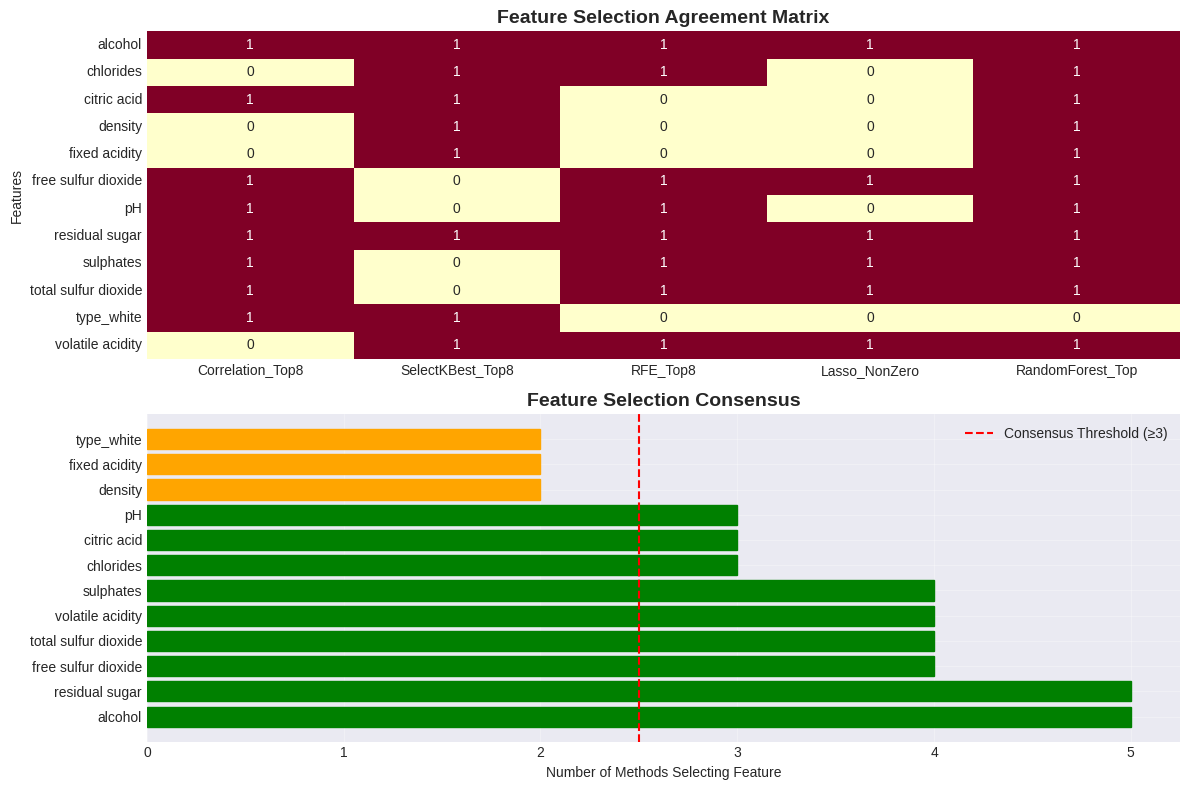

In [184]:
# ====================================================
# CELL 13: COMPARE SELECTED FEATURES
# ====================================================
print("STEP 5: COMPARE SELECTED FEATURES")
print("-"*40)
print("FEATURE SELECTION METHODS COMPARISON")
print("-"*40)

# Collect all selected features from different methods
# Note: For Correlation, we'll use top 8 features from correlation with target
top_corr_features = target_corr_df.nlargest(8, 'Correlation')['Feature'].tolist()

all_selected_features = {
    'Correlation_Top8': top_corr_features,
    'SelectKBest_Top8': selected_features_kbest,
    'RFE_Top8': selected_features_rfe,
    'Lasso_NonZero': selected_features_lasso,
    'RandomForest_Top': selected_features_rf
}

print("\nFEATURES SELECTED BY EACH METHOD:")
print("-"*50)
for method, features in all_selected_features.items():
    print(f"{method}:")
    for feat in features:
        print(f"  • {feat}")
    print()

# Create comparison DataFrame
all_features = set()
for method, features in all_selected_features.items():
    all_features.update(features)

comparison_matrix = pd.DataFrame(index=sorted(all_features))

for method, features in all_selected_features.items():
    comparison_matrix[method] = comparison_matrix.index.isin(features)

print("\nFEATURE SELECTION COMPARISON MATRIX:")
print("-"*50)
print("✓ = Selected, ✗ = Not Selected")
print()

# Display as checkmarks
display_df = comparison_matrix.copy()
display_df = display_df.replace({True: '✓', False: '✗'})
print(display_df.to_string())

# Calculate agreement scores
print("\nMETHOD AGREEMENT ANALYSIS:")
print("-"*40)

# Count how many methods selected each feature
comparison_matrix['Selection_Count'] = comparison_matrix.sum(axis=1)

agreement_df = pd.DataFrame({
    'Feature': comparison_matrix.index,
    'Methods_Selected': comparison_matrix['Selection_Count'],
    'Selection_Rate': comparison_matrix['Selection_Count'] / len(all_selected_features)
}).sort_values('Methods_Selected', ascending=False)

print(agreement_df.to_string(index=False))

# Identify consensus features (selected by at least 3 methods)
consensus_features = agreement_df[agreement_df['Methods_Selected'] >= 3]['Feature'].tolist()

print(f"\nCONSENSUS FEATURES (Selected by ≥ 3 methods):")
print("-"*40)
for i, feat in enumerate(consensus_features, 1):
    count = agreement_df[agreement_df['Feature'] == feat]['Methods_Selected'].values[0]
    print(f"   {i}. {feat} (Selected by {count} methods)")

# Visualize selection agreement
plt.figure(figsize=(12, 8))

# Create heatmap
plt.subplot(2, 1, 1)
sns.heatmap(comparison_matrix.drop('Selection_Count', axis=1).astype(int),
            annot=True, fmt='d', cmap='YlOrRd', cbar=False)
plt.title('Feature Selection Agreement Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Features')

# Create bar chart of selection counts
plt.subplot(2, 1, 2)
bars = plt.barh(agreement_df['Feature'], agreement_df['Methods_Selected'])
plt.xlabel('Number of Methods Selecting Feature')
plt.title('Feature Selection Consensus', fontsize=14, fontweight='bold')
plt.axvline(x=2.5, color='red', linestyle='--', label='Consensus Threshold (≥3)')
plt.legend()
plt.grid(True, alpha=0.3)

# Color bars
for bar, count in zip(bars, agreement_df['Methods_Selected']):
    if count >= 3:
        bar.set_color('green')
    elif count == 2:
        bar.set_color('orange')
    else:
        bar.set_color('red')

plt.tight_layout()
plt.show()

print("="*60)

STEP 5: FINAL FEATURE SELECTION & VALIDATION
----------------------------------------
FINAL SELECTED FEATURES BASED ON CONSENSUS:
----------------------------------------
             Feature  Corr_with_Target  RF_Importance  KBest_Score  Selected_By_Methods
             alcohol            0.4446         0.2598    1506.7101                    5
      residual sugar           -0.0368         0.0674      17.6179                    5
 free sulfur dioxide            0.0699         0.0933      15.8441                    4
total sulfur dioxide           -0.0387         0.0734      13.5588                    4
    volatile acidity           -0.2592         0.1135     400.0417                    4
           sulphates            0.0503         0.0796       9.1732                    4
           chlorides           -0.2560         0.0649     227.1385                    3
         citric acid            0.0953         0.0609      52.4782                    3
                  pH            0.019

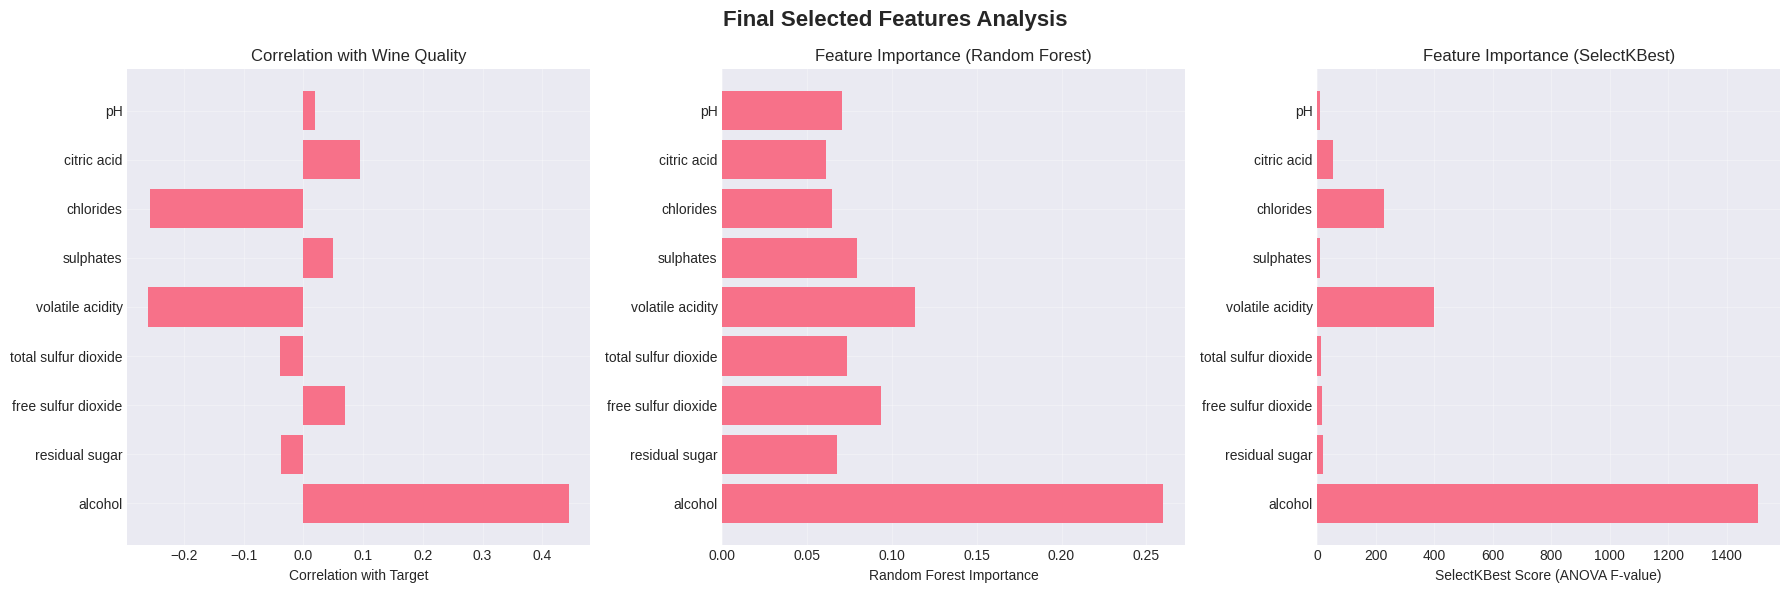


MODEL PERFORMANCE VALIDATION:
----------------------------------------

PERFORMANCE COMPARISON:
----------------------------------------
            Model  Num_Features    MSE  R2_Score  MSE_Reduction
     All Features            12 0.4988    0.3585          0.000
Selected Features             9 0.4993    0.3578         -0.114

✓ Validation PASSED: Selected features maintain similar performance
   (MSE increased by only 0.1%)

FEATURE ENGINEERING & SELECTION COMPLETE!


In [185]:
# ====================================================
# CELL 14: FINAL FEATURE SELECTION & VALIDATION
# ====================================================
print("STEP 5: FINAL FEATURE SELECTION & VALIDATION")
print("-"*40)

if 'consensus_features' in locals():
    print("FINAL SELECTED FEATURES BASED ON CONSENSUS:")
    print("-"*40)

    final_features = consensus_features

    # Display final features with their characteristics
    feature_info = []
    for feat in final_features:
        # Get correlation with target
        corr_with_target = target_correlation[feat] if feat in target_correlation.index else 0

        # Get importance from different methods
        rf_imp = rf_importance[rf_importance['Feature'] == feat]['Importance'].values[0] if feat in rf_importance['Feature'].values else 0
        kbest_score = feature_scores[feature_scores['Feature'] == feat]['Score'].values[0] if feat in feature_scores['Feature'].values else 0

        feature_info.append({
            'Feature': feat,
            'Corr_with_Target': corr_with_target,
            'RF_Importance': rf_imp,
            'KBest_Score': kbest_score,
            'Selected_By_Methods': agreement_df[agreement_df['Feature'] == feat]['Methods_Selected'].values[0]
        })

    final_df = pd.DataFrame(feature_info).round(4)
    print(final_df.to_string(index=False))

    print(f"\nSUMMARY:")
    print(f"• Total features in dataset: {len(X.columns)}")
    print(f"• Final selected features: {len(final_features)}")
    print(f"• Feature reduction: {((len(X.columns) - len(final_features)) / len(X.columns) * 100):.1f}%")

    # Visualize final feature characteristics
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Final Selected Features Analysis', fontsize=16, fontweight='bold')

    # 1. Correlation with target
    axes[0].barh(final_df['Feature'], final_df['Corr_with_Target'])
    axes[0].set_xlabel('Correlation with Target')
    axes[0].set_title('Correlation with Wine Quality')
    axes[0].grid(True, alpha=0.3)

    # 2. Random Forest Importance
    axes[1].barh(final_df['Feature'], final_df['RF_Importance'])
    axes[1].set_xlabel('Random Forest Importance')
    axes[1].set_title('Feature Importance (Random Forest)')
    axes[1].grid(True, alpha=0.3)

    # 3. SelectKBest Score
    axes[2].barh(final_df['Feature'], final_df['KBest_Score'])
    axes[2].set_xlabel('SelectKBest Score (ANOVA F-value)')
    axes[2].set_title('Feature Importance (SelectKBest)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Model Performance Comparison
    print("\nMODEL PERFORMANCE VALIDATION:")
    print("-"*40)

    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_squared_error, r2_score

    try:
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Train models with all features vs selected features
        models = {
            'All Features': RandomForestRegressor(n_estimators=100, random_state=42),
            'Selected Features': RandomForestRegressor(n_estimators=100, random_state=42)
        }

        results = []

        # Model with all features
        models['All Features'].fit(X_train, y_train)
        y_pred_all = models['All Features'].predict(X_test)
        mse_all = mean_squared_error(y_test, y_pred_all)
        r2_all = r2_score(y_test, y_pred_all)
        results.append(['All Features', len(X.columns), mse_all, r2_all])

        # Model with selected features
        X_train_selected = X_train[final_features]
        X_test_selected = X_test[final_features]

        models['Selected Features'].fit(X_train_selected, y_train)
        y_pred_selected = models['Selected Features'].predict(X_test_selected)
        mse_selected = mean_squared_error(y_test, y_pred_selected)
        r2_selected = r2_score(y_test, y_pred_selected)
        results.append(['Selected Features', len(final_features), mse_selected, r2_selected])

        # Create results DataFrame
        results_df = pd.DataFrame(results, columns=['Model', 'Num_Features', 'MSE', 'R2_Score'])
        results_df['MSE_Reduction'] = ((results_df['MSE'].iloc[0] - results_df['MSE']) / results_df['MSE'].iloc[0] * 100)

        print("\nPERFORMANCE COMPARISON:")
        print("-"*40)
        print(results_df.round(4).to_string(index=False))

        if mse_selected <= mse_all * 1.1:  # Allow 10% tolerance
            print(f"\n✓ Validation PASSED: Selected features maintain similar performance")
            print(f"   (MSE increased by only {((mse_selected/mse_all)-1)*100:.1f}%)")
        else:
            print(f"\n⚠ Validation WARNING: Selected features show performance degradation")
            print(f"   (MSE increased by {((mse_selected/mse_all)-1)*100:.1f}%)")

    except Exception as e:
        print(f"Model validation skipped due to error: {e}")

print("\n" + "="*60)
print("FEATURE ENGINEERING & SELECTION COMPLETE!")
print("="*60)